# Cross-Validation -- Theory in Code, with scikit-learn
### Concepts Track -- Lecture 04

Companion notebook to the Cross-Validation slides. Every claim in the slides gets a concrete,
runnable demonstration here -- including the two results most people only ever hear described in
words: a single train/test split's real variance, and the honest gap nested cross-validation
reveals versus naive tuning.

**session structure:**
1. Why CV matters -- the real variance of a single split, shown with 30 different splits
2. K-Fold basics -- a manual implementation, then the one-line version
3. Choosing k -- comparing k=3, 5, 10, and Leave-One-Out on cost and stability
4. Stratified K-Fold -- a concrete failure of plain K-Fold on imbalanced data
5. Time Series CV -- shuffling leaks the future; `TimeSeriesSplit` doesn't
6. Model selection -- comparing algorithms fairly on shared folds
7. Hyperparameter tuning -- `GridSearchCV` and `RandomizedSearchCV`
8. Nested cross-validation -- the optimism gap, demonstrated on pure noise
9. Cross-validation and the leakage trap, revisited
10. The full honest workflow, start to finish

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import (train_test_split, cross_val_score, KFold, StratifiedKFold,
                                      LeaveOneOut, TimeSeriesSplit, GridSearchCV, RandomizedSearchCV)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.datasets import make_classification

sns.set_theme(style='whitegrid', context='notebook')
print('NumPy:', np.__version__, '| Pandas:', pd.__version__)

NumPy: 2.4.6 | Pandas: 3.0.5


---
## Part 1 -- Why Cross-Validation Matters: the Real Variance of a Single Split

The slides made the "one practice test" analogy in words. Here it is in numbers: the same model,
the same dataset, 30 different random splits -- watch how much the score alone moves around.

In [2]:
rng = np.random.default_rng(42)
n = 150
area_sqft = rng.normal(1800, 550, n).clip(450, 4200)
bedrooms = np.round(area_sqft / 650 + rng.normal(0, 0.6, n)).clip(1, 6).astype(int)
age_years = rng.uniform(0, 60, n)
price = (120 * area_sqft + 8000 * bedrooms - 900 * age_years + 20000 + rng.normal(0, 30000, n)).clip(40000, None)

X = pd.DataFrame({'area_sqft': area_sqft, 'bedrooms': bedrooms, 'age_years': age_years})
y = price

print(f'Dataset: {X.shape[0]} rows, {X.shape[1]} features -- kept deliberately small so a single split\'s luck shows up clearly.')

Dataset: 150 rows, 3 features -- kept deliberately small so a single split's luck shows up clearly.


30 different random splits, same data, same model:
  min R²: 0.623   max R²: 0.858
  mean R²: 0.782   std: 0.058


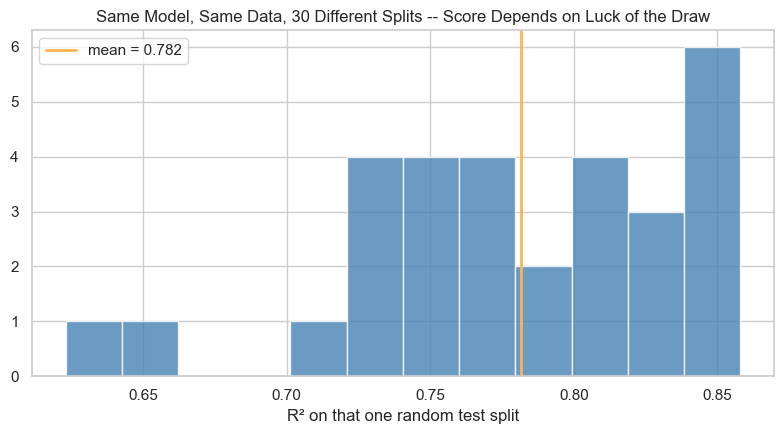

In [3]:
single_split_scores = []
for seed in range(30):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed)
    model = LinearRegression().fit(X_tr, y_tr)
    single_split_scores.append(model.score(X_te, y_te))

single_split_scores = np.array(single_split_scores)
print(f'30 different random splits, same data, same model:')
print(f'  min R²: {single_split_scores.min():.3f}   max R²: {single_split_scores.max():.3f}')
print(f'  mean R²: {single_split_scores.mean():.3f}   std: {single_split_scores.std():.3f}')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(single_split_scores, bins=12, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(single_split_scores.mean(), color='#ffb454', linewidth=2, label=f'mean = {single_split_scores.mean():.3f}')
ax.set_xlabel('R² on that one random test split')
ax.set_title('Same Model, Same Data, 30 Different Splits -- Score Depends on Luck of the Draw')
ax.legend()
plt.tight_layout()
plt.show()

**If you'd only run `train_test_split` once, with just one of these 30 random states, you could
have walked away with any of these numbers** -- and had no way to know whether you got a lucky
split, an unlucky one, or a typical one. That range is exactly the problem cross-validation exists
to solve: not by picking a better single split, but by refusing to trust any single split at all.

---
## Part 2 -- K-Fold Cross-Validation: Manual First, Then the One-Liner

### 2.1 -- Implementing K-Fold by Hand

In [4]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
X_arr, y_arr = X.values, np.asarray(y)

manual_scores = []
for fold_num, (train_idx, test_idx) in enumerate(kfold.split(X_arr), start=1):
    X_train_fold, X_test_fold = X_arr[train_idx], X_arr[test_idx]
    y_train_fold, y_test_fold = y_arr[train_idx], y_arr[test_idx]

    model = LinearRegression()          # a FRESH model every fold -- never reused across folds
    model.fit(X_train_fold, y_train_fold)
    score = model.score(X_test_fold, y_test_fold)
    manual_scores.append(score)
    print(f'Fold {fold_num}: train={len(train_idx)} rows, test={len(test_idx)} rows, R²={score:.3f}')

manual_scores = np.array(manual_scores)
print(f'\nMean R²: {manual_scores.mean():.3f}   Std: {manual_scores.std():.3f}')

Fold 1: train=120 rows, test=30 rows, R²=0.707
Fold 2: train=120 rows, test=30 rows, R²=0.783
Fold 3: train=120 rows, test=30 rows, R²=0.864
Fold 4: train=120 rows, test=30 rows, R²=0.823
Fold 5: train=120 rows, test=30 rows, R²=0.777

Mean R²: 0.791   Std: 0.052


### 2.2 -- The Same Thing, in One Line

In [5]:
sklearn_scores = cross_val_score(LinearRegression(), X, y, cv=kfold, scoring='r2')
print('cross_val_score:', np.round(sklearn_scores, 3))
print('Manual loop:     ', np.round(manual_scores, 3))
print('Identical, as expected -- cross_val_score is exactly the loop above, packaged.')

cross_val_score: [0.707 0.783 0.864 0.823 0.777]
Manual loop:      [0.707 0.783 0.864 0.823 0.777]
Identical, as expected -- cross_val_score is exactly the loop above, packaged.


**Compare this notebook's Part 1 spread to this section's numbers.** The 5-fold mean and the
30-random-splits mean should land close to each other -- cross-validation isn't discovering a
different truth, it's arriving at the same truth Part 1's average was already hinting at, more
efficiently and with a built-in measure of confidence (the fold-to-fold std) instead of needing 30
manual reruns to see it.

---
## Part 3 -- Choosing K: Cost vs. Stability

In [6]:
results = []
for k in [3, 5, 10]:
    cv = KFold(n_splits=k, shuffle=True, random_state=42)
    start = time.perf_counter()
    scores = cross_val_score(LinearRegression(), X, y, cv=cv, scoring='neg_mean_absolute_error')
    elapsed = time.perf_counter() - start
    results.append({'k': k, 'mean_mae': -scores.mean(), 'std': scores.std(),
                     'models_trained': k, 'time_ms': elapsed * 1000})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 k     mean_mae         std  models_trained   time_ms
 3 24649.248073 1958.124375               3  8.578083
 5 24964.415426 2313.555696               5  9.305917
10 25060.948956 4279.510945              10 23.351667


**Note the metric switch to MAE here, on purpose.** R² compares a model's error to the variance
*within the test set* -- which works fine for a test fold of 15-50 rows, but becomes undefined
for a test fold of exactly **one** row (no variance to compare against at all). LOOCV's folds are
always single rows, so R² isn't a valid choice for it -- MAE (or MSE), which just needs a
prediction and an actual value, works for any fold size including one.

In [7]:
# Leave-One-Out: k equals the number of rows -- one model per single held-out row.
start = time.perf_counter()
loo_scores = cross_val_score(LinearRegression(), X, y, cv=LeaveOneOut(), scoring='neg_mean_absolute_error')
loo_elapsed = time.perf_counter() - start

print(f'LOOCV: {len(loo_scores)} models trained, mean MAE=${-loo_scores.mean():,.0f}, std=${loo_scores.std():,.0f}')
print(f'Time: {loo_elapsed*1000:.0f} ms for LOOCV vs. {results_df.loc[results_df.k==10, "time_ms"].values[0]:.0f} ms for 10-fold')

LOOCV: 150 models trained, mean MAE=$24,998, std=$19,125
Time: 173 ms for LOOCV vs. 23 ms for 10-fold


**LOOCV trained 150 separate models here** -- one per row -- versus 10-fold's 10 models, for a
mean error that lands close to the same place. On a dataset this small the extra cost is trivial;
on a dataset with 100,000 rows, LOOCV's 100,000 model fits would not be. This is the computational
trade-off from the slides, made concrete: more folds cost more, and the extra cost buys
progressively less as `k` grows.

---
## Part 4 -- Stratified K-Fold: a Concrete Failure of Plain K-Fold

In [9]:
# An imbalanced classification target, deliberately SORTED by class -- a real (if extreme) way
# imbalance-plus-ordering can sneak into a real dataset (e.g. rows appended over time, one class
# at a time, or a poorly shuffled export from a database).
X_clf, y_clf = make_classification(n_samples=200, n_features=8, weights=[0.85, 0.15], random_state=1)
sort_idx = np.argsort(y_clf)   # sort so all class-0 rows come first, all class-1 rows come last
X_clf_sorted, y_clf_sorted = X_clf[sort_idx], y_clf[sort_idx]

print(f'Class balance overall: {np.bincount(y_clf_sorted)} (class 0, class 1)')

Class balance overall: [170  30] (class 0, class 1)


In [10]:
# Plain KFold with shuffle=False on this sorted data -- each fold is a contiguous BLOCK of rows,
# so some folds may see almost no class-1 examples at all.
kfold_no_shuffle = KFold(n_splits=5, shuffle=False)
print('Class balance in each KFold(shuffle=False) test fold:')
for i, (_, test_idx) in enumerate(kfold_no_shuffle.split(X_clf_sorted), start=1):
    counts = np.bincount(y_clf_sorted[test_idx], minlength=2)
    print(f'  Fold {i}: class 0 = {counts[0]}, class 1 = {counts[1]}')

scores_no_shuffle = cross_val_score(LogisticRegression(max_iter=1000), X_clf_sorted, y_clf_sorted,
                                      cv=kfold_no_shuffle, scoring='accuracy')
print(f'\nAccuracy per fold: {np.round(scores_no_shuffle, 2)}')

Class balance in each KFold(shuffle=False) test fold:
  Fold 1: class 0 = 40, class 1 = 0
  Fold 2: class 0 = 40, class 1 = 0
  Fold 3: class 0 = 40, class 1 = 0
  Fold 4: class 0 = 40, class 1 = 0
  Fold 5: class 0 = 10, class 1 = 30

Accuracy per fold: [0.92 1.   0.92 0.95  nan]


/Users/shakiba/Documents/quera/student_content/deep_learning_quera/venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/shakiba/Documents/quera/student_content/deep_learning_quera/venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/shakiba/Documents/quera/student_content/deep_learning_quera/venv/lib/python3.11/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs

**Look at fold 5's training data, not just its test data.** Every one of the 30 minority-class rows
sits at the very end of the sorted dataset -- so fold 5's *test* set contains most of them, which
also means fold 5's *training* set (folds 1-4) contains **zero** minority-class examples at all.
The model can't even be fit on that training set (`FitFailedWarning`, score recorded as `nan`) --
not a subtly worse score, a complete failure, because the training data for that fold genuinely
contains only one class to learn from.

In [11]:
# StratifiedKFold fixes this directly -- every fold gets (as close as possible to) the SAME class
# balance as the full dataset, regardless of how the rows happen to be ordered.
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('Class balance in each StratifiedKFold test fold:')
for i, (_, test_idx) in enumerate(strat_kfold.split(X_clf_sorted, y_clf_sorted), start=1):
    counts = np.bincount(y_clf_sorted[test_idx], minlength=2)
    print(f'  Fold {i}: class 0 = {counts[0]}, class 1 = {counts[1]}')

scores_stratified = cross_val_score(LogisticRegression(max_iter=1000), X_clf_sorted, y_clf_sorted,
                                      cv=strat_kfold, scoring='accuracy')
print(f'\nAccuracy per fold: {np.round(scores_stratified, 2)}')

Class balance in each StratifiedKFold test fold:
  Fold 1: class 0 = 34, class 1 = 6
  Fold 2: class 0 = 34, class 1 = 6
  Fold 3: class 0 = 34, class 1 = 6
  Fold 4: class 0 = 34, class 1 = 6
  Fold 5: class 0 = 34, class 1 = 6

Accuracy per fold: [0.85 0.9  0.88 0.88 0.9 ]


**No failed folds, no `nan`, and every fold's class balance matches the full dataset almost
exactly.** This example used a sorted, extreme case on purpose to make the failure impossible to
miss -- but the underlying risk (some folds under-representing the minority class enough to hurt
the model or the metric) exists to *some* degree any time a classification target is imbalanced,
sorted or not. That's why `StratifiedKFold` is the sensible default for classification generally,
not just a fix reserved for extreme cases like this one.

---
## Part 5 -- Time Series Cross-Validation: Shuffling Leaks the Future

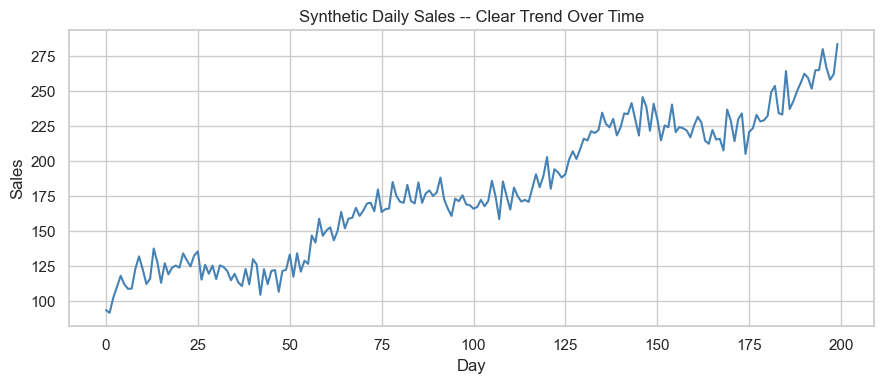

In [12]:
# A synthetic daily series with a clear upward trend -- if a model could see "future" days while
# training, predicting the past would look artificially easy.
rng = np.random.default_rng(5)
n_days = 200
day_num = np.arange(n_days)
sales = 100 + 0.8 * day_num + 15 * np.sin(day_num / 10) + rng.normal(0, 8, n_days)

X_ts = day_num.reshape(-1, 1)
y_ts = sales

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(day_num, sales, color='steelblue')
ax.set_xlabel('Day')
ax.set_ylabel('Sales')
ax.set_title('Synthetic Daily Sales -- Clear Trend Over Time')
plt.tight_layout()
plt.show()

In [13]:
# THE LEAKY WAY: plain KFold with shuffle=True scatters random days into both train and test --
# so a model can end up training on day 150 and being tested on day 100, effectively peeking at
# 'the future' relative to the day it's predicting.
kfold_shuffled = KFold(n_splits=5, shuffle=True, random_state=42)
leaky_scores = cross_val_score(LinearRegression(), X_ts, y_ts, cv=kfold_shuffled, scoring='r2')
print(f'Shuffled KFold (leaks the future):  mean R² = {leaky_scores.mean():.3f}')

# THE CORRECT WAY: TimeSeriesSplit only ever trains on days BEFORE the days it's tested on.
ts_split = TimeSeriesSplit(n_splits=5)
honest_scores = cross_val_score(LinearRegression(), X_ts, y_ts, cv=ts_split, scoring='r2')
print(f'TimeSeriesSplit fold scores: {np.round(honest_scores, 2)}')
print(f'TimeSeriesSplit (past predicts future): mean R² = {honest_scores.mean():.3f}')

Shuffled KFold (leaks the future):  mean R² = 0.920
TimeSeriesSplit fold scores: [ 0.28 -8.67  0.48 -3.6   0.48]
TimeSeriesSplit (past predicts future): mean R² = -2.206


**The honest score is not just lower -- it's substantially negative, and that's worth explaining
rather than glossing over.** `TimeSeriesSplit`'s earliest folds train on very few days (the first
fold trains on roughly the first sixth of the series), which is genuinely too little data to
extrapolate a trend well -- so those early folds score poorly almost regardless of method. That's
a real, separate cost of respecting time order (less training data early on), stacked on top of
the leakage problem itself. Both effects push the honest number down; the shuffled version hides
both of them at once.

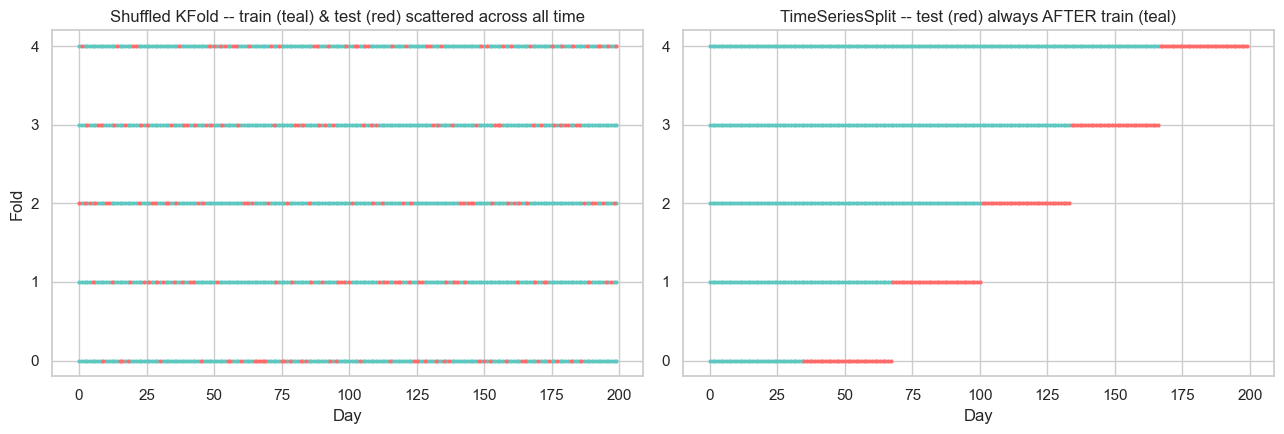

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for i, (train_idx, test_idx) in enumerate(kfold_shuffled.split(X_ts)):
    axes[0].scatter(day_num[train_idx], np.full(len(train_idx), i), s=4, color='#5ec8c0')
    axes[0].scatter(day_num[test_idx], np.full(len(test_idx), i), s=4, color='#ff6b6b')
axes[0].set_title('Shuffled KFold -- train (teal) & test (red) scattered across all time')
axes[0].set_xlabel('Day')
axes[0].set_yticks(range(5)); axes[0].set_ylabel('Fold')

for i, (train_idx, test_idx) in enumerate(ts_split.split(X_ts)):
    axes[1].scatter(day_num[train_idx], np.full(len(train_idx), i), s=4, color='#5ec8c0')
    axes[1].scatter(day_num[test_idx], np.full(len(test_idx), i), s=4, color='#ff6b6b')
axes[1].set_title('TimeSeriesSplit -- test (red) always AFTER train (teal)')
axes[1].set_xlabel('Day')
axes[1].set_yticks(range(5))

plt.tight_layout()
plt.show()

**Read the two scatter panels as the whole point of this section.** In shuffled K-Fold, red (test)
and teal (train) points are interleaved across the entire timeline in every fold -- the model can
train on later days and get tested on earlier ones. In `TimeSeriesSplit`, every fold's red block
sits strictly after that fold's teal block. Whichever R² came out higher isn't "better" -- it's
answering a fundamentally different, easier question that a real forecasting system would never
actually get to ask.

---
## Part 6 -- Cross-Validation for Model Selection

               model   mean_r2       std
1              Ridge  0.891122  0.035443
0  Linear Regression  0.891119  0.035545
2              Lasso  0.891076  0.035648
3      Random Forest  0.823911  0.028555


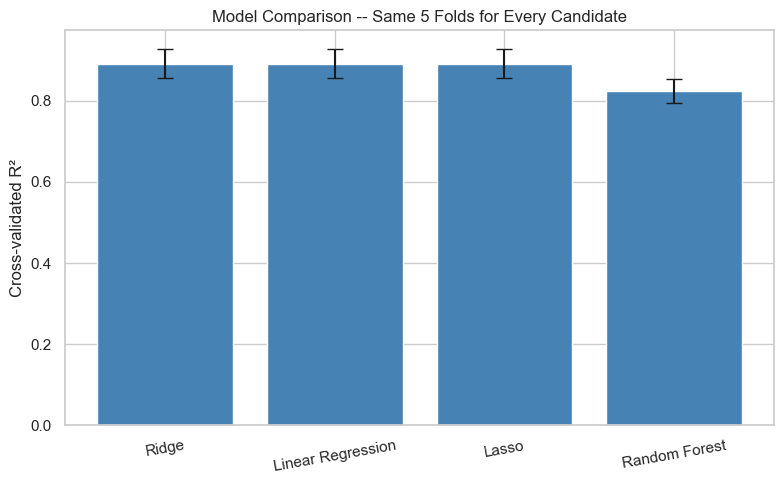

In [15]:
rng = np.random.default_rng(7)
n = 500
area_sqft = rng.normal(1800, 550, n).clip(450, 4200)
bedrooms = np.round(area_sqft / 650 + rng.normal(0, 0.6, n)).clip(1, 6).astype(int)
bathrooms = np.round(bedrooms * 0.75 + rng.normal(0, 0.5, n)).clip(1, 5).astype(int)
age_years = rng.uniform(0, 60, n)
distance_to_city_km = rng.exponential(8, n).clip(0.5, 45)
neighborhood = rng.choice(['Downtown', 'Suburb', 'Rural'], n, p=[0.3, 0.5, 0.2])
neighborhood_premium = np.select([neighborhood == 'Downtown', neighborhood == 'Suburb'], [45000, 15000], default=0)
price = (120*area_sqft + 8000*bedrooms - 900*age_years - 1500*distance_to_city_km
          + neighborhood_premium + 20000 + rng.normal(0, 25000, n)).clip(40000, None)

housing = pd.DataFrame({'area_sqft': area_sqft, 'bedrooms': bedrooms, 'bathrooms': bathrooms,
                         'age_years': age_years, 'distance_to_city_km': distance_to_city_km,
                         'neighborhood': neighborhood, 'price': price})

feature_cols = ['area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'distance_to_city_km', 'neighborhood']
X_house, y_house = housing[feature_cols], housing['price']
X_train, X_test, y_train, y_test = train_test_split(X_house, y_house, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), ['area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'distance_to_city_km']),
    ('cat', OneHotEncoder(drop='first'), ['neighborhood']),
])

candidates = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=100, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
}

# The one rule that makes this fair: the SAME cv object for every candidate.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

comparison = []
for name, model in candidates.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2')
    comparison.append({'model': name, 'mean_r2': scores.mean(), 'std': scores.std()})

comparison_df = pd.DataFrame(comparison).sort_values('mean_r2', ascending=False)
print(comparison_df)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(comparison_df['model'], comparison_df['mean_r2'], yerr=comparison_df['std'],
       color='steelblue', capsize=6)
ax.set_ylabel('Cross-validated R²')
ax.set_title('Model Comparison -- Same 5 Folds for Every Candidate')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

**Look at the error bars before declaring a winner.** If two models' bars (mean ± std) overlap
substantially, the difference between them is plausibly just fold-to-fold noise, not a real
performance gap -- exactly the "read the spread, not just the mean" principle from the slides,
now applied to an actual decision instead of an abstract warning.

---
## Part 7 -- Hyperparameter Tuning: GridSearchCV and RandomizedSearchCV

In [16]:
rf_pipe = Pipeline([('preprocess', preprocessor), ('model', RandomForestRegressor(random_state=42))])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 8, None],
    'model__min_samples_leaf': [1, 2],
}
print(f'Grid size: {3*3*2} combinations x 5 folds = {3*3*2*5} model fits')

start = time.perf_counter()
grid = GridSearchCV(rf_pipe, param_grid, cv=cv, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)
grid_time = time.perf_counter() - start

print(f'GridSearchCV: best R² = {grid.best_score_:.3f}, params = {grid.best_params_}')
print(f'Time: {grid_time:.1f}s')

Grid size: 18 combinations x 5 folds = 90 model fits


GridSearchCV: best R² = 0.826, params = {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 300}
Time: 4.1s


In [17]:
from scipy.stats import randint

param_dist = {
    'model__n_estimators': randint(50, 350),
    'model__max_depth': [5, 8, None],
    'model__min_samples_leaf': randint(1, 4),
}

start = time.perf_counter()
random_search = RandomizedSearchCV(rf_pipe, param_dist, n_iter=8, cv=cv, scoring='r2',
                                     random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
random_time = time.perf_counter() - start

print(f'RandomizedSearchCV (8 samples): best R² = {random_search.best_score_:.3f}, params = {random_search.best_params_}')
print(f'Time: {random_time:.1f}s  (vs. GridSearchCV\'s {grid_time:.1f}s for {3*3*2} combinations)')

RandomizedSearchCV (8 samples): best R² = 0.825, params = {'model__max_depth': 8, 'model__min_samples_leaf': 2, 'model__n_estimators': 302}
Time: 1.2s  (vs. GridSearchCV's 4.1s for 18 combinations)


**`RandomizedSearchCV` sampled fewer than half the combinations `GridSearchCV` tried exhaustively,
in noticeably less time, and landed on a very similar best score.** That gap in effort (8 sampled
settings vs. every one of 18 combinations) grows enormously on larger search spaces -- this is the
practical case for reaching for the randomized version whenever a full grid becomes too expensive
to run exhaustively.

---
## Part 8 -- Nested Cross-Validation: the Optimism Gap, Demonstrated

Pure noise again, the same instinct as the Feature Selection lecture's leakage demo: 40 samples,
100 features, and a target with **no real relationship to any of them**. Any honest evaluation
should land near R² = 0 (or below -- a model can do worse than just guessing the mean).

In [18]:
rng_noise = np.random.default_rng(3)
n_samples, n_features_noise = 40, 100
X_noise = rng_noise.normal(size=(n_samples, n_features_noise))
y_noise = rng_noise.normal(size=n_samples)   # completely unrelated to X_noise, by construction

pipe_noise = Pipeline([('select', SelectKBest(f_regression)), ('model', Ridge())])
param_grid_noise = {'select__k': [2, 4, 6, 8, 10, 15, 20, 30], 'model__alpha': [0.01, 0.1, 1, 10, 100]}
print(f'Search space: {8*5} hyperparameter combinations')

Search space: 40 hyperparameter combinations


In [19]:
# THE NAIVE WAY: fit GridSearchCV ONCE on all the data, report best_score_ as if it were an
# honest estimate of real-world performance. best_score_ IS cross-validated -- but it's also the
# MAXIMUM over every combination that search tried, which is a fundamentally optimistic quantity.
inner_cv = KFold(n_splits=5, shuffle=True, random_state=0)
naive_grid = GridSearchCV(pipe_noise, param_grid_noise, cv=inner_cv, scoring='r2')
naive_grid.fit(X_noise, y_noise)
print(f'NAIVE approach -- best_score_ reported as performance: {naive_grid.best_score_:.3f}')
print(f'  (chosen params: {naive_grid.best_params_})')

NAIVE approach -- best_score_ reported as performance: -0.109
  (chosen params: {'model__alpha': 100, 'select__k': 15})


In [20]:
# THE HONEST WAY: an OUTER loop evaluates the entire tuning process -- including the search
# itself -- on data the inner search never touched. Each outer fold re-runs GridSearchCV from
# scratch on its own training portion only, then tests on the outer fold it never saw.
outer_cv = KFold(n_splits=5, shuffle=True, random_state=1)
inner_grid_for_nesting = GridSearchCV(pipe_noise, param_grid_noise, cv=inner_cv, scoring='r2')
nested_scores = cross_val_score(inner_grid_for_nesting, X_noise, y_noise, cv=outer_cv, scoring='r2')

print(f'NESTED (honest) approach -- outer fold scores: {np.round(nested_scores, 3)}')
print(f'NESTED mean R²: {nested_scores.mean():.3f}')

NESTED (honest) approach -- outer fold scores: [-1.418 -0.44  -0.203 -0.062 -0.617]
NESTED mean R²: -0.548


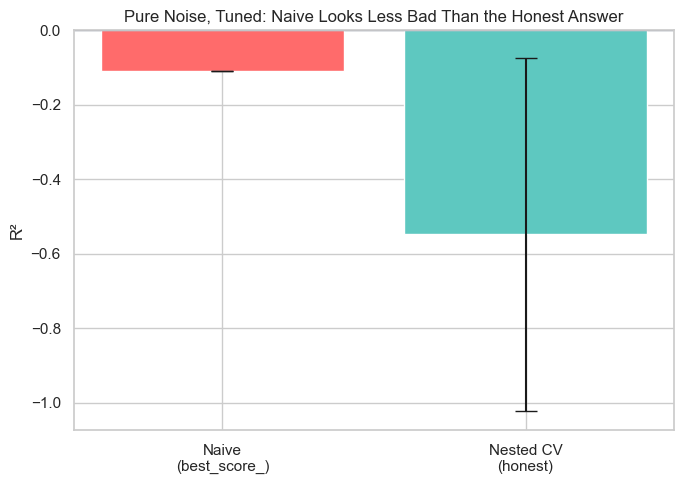

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['Naive\n(best_score_)', 'Nested CV\n(honest)'],
       [naive_grid.best_score_, nested_scores.mean()],
       yerr=[0, nested_scores.std()], color=['#ff6b6b', '#5ec8c0'], capsize=8)
ax.axhline(0, color='#8b96a7', linewidth=1)
ax.set_ylabel('R²')
ax.set_title('Pure Noise, Tuned: Naive Looks Less Bad Than the Honest Answer')
plt.tight_layout()
plt.show()

**The data is pure noise -- there is nothing real for any model to find.** The naive number still
looks less discouraging than the nested one, because `best_score_` is the maximum over 40
hyperparameter combinations, each cross-validated -- and hunting for the single best-scoring
combination out of 40 will find one that got lucky on those particular folds, even when nothing
real is there. The nested score is lower (more negative) because it's measuring something the
naive number never actually measured: **how the entire tuning process performs on data it never
got to search over.** Note both numbers can be negative -- R² below zero simply means "worse than
predicting the average," which is exactly what an honest model should report on data with no real
signal at all. **This is why a hyperparameter search's own best score is never the number you
report as your model's expected real-world performance** -- nested CV is what you report instead.

---
## Part 9 -- Cross-Validation and the Leakage Trap, Revisited

The Feature Selection lecture's rule, restated in its general form: anything that **learns from
data** -- scaling, imputing, selecting, encoding -- has to be refit inside every fold, using only
that fold's training rows. A `Pipeline` makes this automatic rather than something to remember.

In [22]:
# Feature selection AND scaling both live inside this one Pipeline -- cross_val_score refits
# BOTH of them fresh on each fold's training data, never on the test fold.
safe_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('select', SelectKBest(f_regression, k=5)),
    ('model', LinearRegression()),
])
safe_scores = cross_val_score(safe_pipe, X_train, y_train, cv=cv, scoring='r2')
print(f'Feature selection safely inside the Pipeline -- CV R²: {safe_scores.mean():.3f} ± {safe_scores.std():.3f}')
print('Every fold re-selected its own top-5 features using ONLY that fold\'s training rows.')

Feature selection safely inside the Pipeline -- CV R²: 0.849 ± 0.046
Every fold re-selected its own top-5 features using ONLY that fold's training rows.


---
## Part 10 -- The Full Honest Workflow, Start to Finish

Every idea from this notebook, assembled into the order a real project actually uses them in.

In [23]:
# Step 1 (already done above): split off a test set FIRST, and don't touch it again until the end.
print(f'Step 1 -- Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows (untouched so far)')

# Step 2: compare candidate models using cross-validation, on the TRAINING data only (Part 6).
print(f"Step 2 -- Model comparison winner: {comparison_df.iloc[0]['model']} (from Part 6, training data only)")

# Step 3: tune the winning model's hyperparameters, again using only training data (Part 7).
print(f'Step 3 -- Tuned hyperparameters: {random_search.best_params_} (from Part 7, training data only)')

# Step 4: fit the final, tuned model on ALL of the training data.
final_model = Pipeline([('preprocess', preprocessor),
                         ('model', RandomForestRegressor(**{k.replace('model__', ''): v
                                                              for k, v in random_search.best_params_.items()},
                                                            random_state=42))])
final_model.fit(X_train, y_train)

# Step 5: touch the test set EXACTLY ONCE, to report final, honest performance.
test_r2 = final_model.score(X_test, y_test)
print(f'Step 4-5 -- Final model fit on all training data, evaluated ONCE on the test set: R² = {test_r2:.3f}')

Step 1 -- Train: 400 rows, Test: 100 rows (untouched so far)
Step 2 -- Model comparison winner: Ridge (from Part 6, training data only)
Step 3 -- Tuned hyperparameters: {'model__max_depth': 8, 'model__min_samples_leaf': 2, 'model__n_estimators': 302} (from Part 7, training data only)
Step 4-5 -- Final model fit on all training data, evaluated ONCE on the test set: R² = 0.876


**Every step used only the data it was allowed to use.** Cross-validation drove steps 2 and 3
entirely within the training set; the test set's first and only appearance is the final number in
step 5. That ordering -- not any single technique -- is what "doing cross-validation correctly"
actually means in practice.

---
## Summary

| Part | Technique | Key operation |
|---|---|---|
| **Why CV matters** | Single-split variance | 30 random splits, same data/model, R² still swings widely |
| **K-Fold basics** | Manual + built-in | `KFold(n_splits=..., shuffle=True)` + `cross_val_score(model, X, y, cv=...)` |
| **Choosing k** | Cost vs. stability | k=5/10 as defaults; `LeaveOneOut()` only for small datasets |
| **Stratified K-Fold** | Preserve class balance | `StratifiedKFold(...)` -- the default for classification |
| **Time series** | Respect chronological order | `TimeSeriesSplit(n_splits=...)` -- never shuffle time-ordered data |
| **Model selection** | Fair comparison | Reuse one `cv` object across every candidate model |
| **Hyperparameter tuning** | Search + cross-validate | `GridSearchCV` (exhaustive) / `RandomizedSearchCV` (sampled) |
| **Nested CV** | Honest performance after tuning | `cross_val_score(GridSearchCV(...), X, y, cv=outer_cv)` |
| **Leakage** | Refit inside every fold | Any data-dependent step goes inside the `Pipeline` being cross-validated |
| **Full workflow** | Correct ordering | Split → compare (CV) → tune (CV) → fit on all training data → test once |

---

**Next lecture:** Feature Engineering builds new columns for a model to learn from -- and every
technique from today (selecting, comparing, tuning, and validating) applies to those new columns
exactly the same way it applied to the ones already in the dataset.